### Individual Homework

#### Enter your name here: Xueying Chen

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Analysis of movies IMDB dataset**

We will look at a ***subset*** sample of movies, taken from the [Kaggle IMDB 5000 movie dataset](https://www.kaggle.com/carolzhangdc/imdb-5000-movie-dataset)

In [2]:
movies = pd.read_csv('../Data/movies.csv')
movies

,title,genre,director,year,duration,gross,budget,cast_facebook_likes,votes,reviews,rating
0,Avatar,Action,James Cameron,2009,178,760505847,237000000,4834,886204,3777,7.9
1,Titanic,Drama,James Cameron,1997,194,658672302,200000000,45223,793059,2843,7.7
2,Jurassic World,Action,Colin Trevorrow,2015,124,652177271,150000000,8458,418214,1934,7.0
3,The Avengers,Action,Joss Whedon,2012,173,623279547,220000000,87697,995415,2425,8.1
4,The Dark Knight,Action,Christopher Nolan,2008,152,533316061,185000000,57802,1676169,5312,9.0
...,...,...,...,...,...,...,...,...,...,...,...
2956,Locker 13,Thriller,Bruce Dellis,2014,95,2468,300000,2048,241,15,4.8
2957,The Ghastly Love of Johnny X,Comedy,Paul Bunnell,2012,106,2436,2000000,1611,344,113,5.7
2958,Detention of the Dead,Comedy,Alex Craig Mann,2012,87,1332,500000,2251,2038,49,4.6
2959,The Trials of Darryl Hunt,Crime,Ricki Stern,2006,106,1111,200000,2,771,21,7.7


Besides the obvious variables of `title`, `genre`, `director`, `year`, and `duration`, the rest of the variables are as follows:

-   `gross` : The gross earnings in the US box office, not adjusted for inflation
-   `budget`: The movie's budget
-   `cast_facebook_likes`: the number of facebook likes cast memebrs received
-   `votes`: the number of people who voted for (or rated) the movie in IMDB
-   `reviews`: the number of reviews for that movie
-   `rating`: IMDB average rating

**Produce a table with the count of movies by genre, ranked in descending order**


In [3]:
movies_by_genre = (
    movies.groupby("genre")
    .size()
    .reset_index(name="movie_count")
    .sort_values("movie_count", ascending=False)
)

movies_by_genre

,genre,movie_count
4,Comedy,848
0,Action,738
7,Drama,498
1,Adventure,288
5,Crime,202
3,Biography,135
10,Horror,131
2,Animation,35
9,Fantasy,28
6,Documentary,25


**Produce a table with the average gross earning and budget (`gross` and `budget`) by genre. Calculate a variable `return_on_budget` which shows how many \$ did a movie make at the box office for each \$ of its budget. Ranked genres by this `return_on_budget` in descending order**

In [4]:
genre_summary = (
    movies.groupby("genre")[["gross", "budget"]]
    .mean()
    .reset_index()
)

genre_summary["return_on_budget"] = (
    genre_summary["gross"] / genre_summary["budget"]
)

genre_summary = genre_summary.sort_values(
    "return_on_budget",
    ascending=False
)

genre_summary

,genre,gross,budget,return_on_budget
11,Musical,9.208400e+07,3.189500e+06,28.870983
8,Family,1.491605e+08,1.483333e+07,10.055763
16,Western,2.082188e+07,3.465000e+06,6.009202
6,Documentary,1.735397e+07,5.887852e+06,2.947420
10,Horror,3.771374e+07,1.350492e+07,2.792593
9,Fantasy,4.240884e+07,1.758214e+07,2.412040
4,Comedy,4.263055e+07,2.444632e+07,1.743843
12,Mystery,6.753302e+07,3.921875e+07,1.721958
2,Animation,9.843379e+07,6.170143e+07,1.595324
3,Biography,4.520181e+07,2.854370e+07,1.583600


**Produce a table that shows the top 15 directors who have created the highest gross revenue in the box office. Don't just show the total gross amount, but also the mean, median, and standard deviation per director**

In [5]:
director_stats = (
    movies.groupby("director")["gross"]
    .agg(["sum", "mean", "median", "std"])
    .sort_values("sum", ascending=False)
    .head(15)
)

director_stats


,sum,mean,median,std
director,,,,
Steven Spielberg,4014061704,1.745244e+08,164435221.0,1.014211e+08
Michael Bay,2231242537,1.716340e+08,138396624.0,1.271616e+08
Tim Burton,2071275480,1.294547e+08,76519172.0,1.087269e+08
Sam Raimi,2014600898,2.014601e+08,234903076.0,1.621266e+08
James Cameron,1909725910,3.182877e+08,175562880.5,3.091713e+08
Christopher Nolan,1813227576,2.266534e+08,196667606.5,1.872241e+08
George Lucas,1741418480,3.482837e+08,380262555.0,1.461939e+08
Robert Zemeckis,1619309108,1.245622e+08,100853835.0,9.130028e+07
Clint Eastwood,1378321100,7.254322e+07,46700000.0,7.548741e+07


**Produce a table that describes how ratings are distributed by genre. We don't want just the mean, but also, min, max, median, SD and some kind of a histogram or density graph that visually shows how ratings are distributed.**

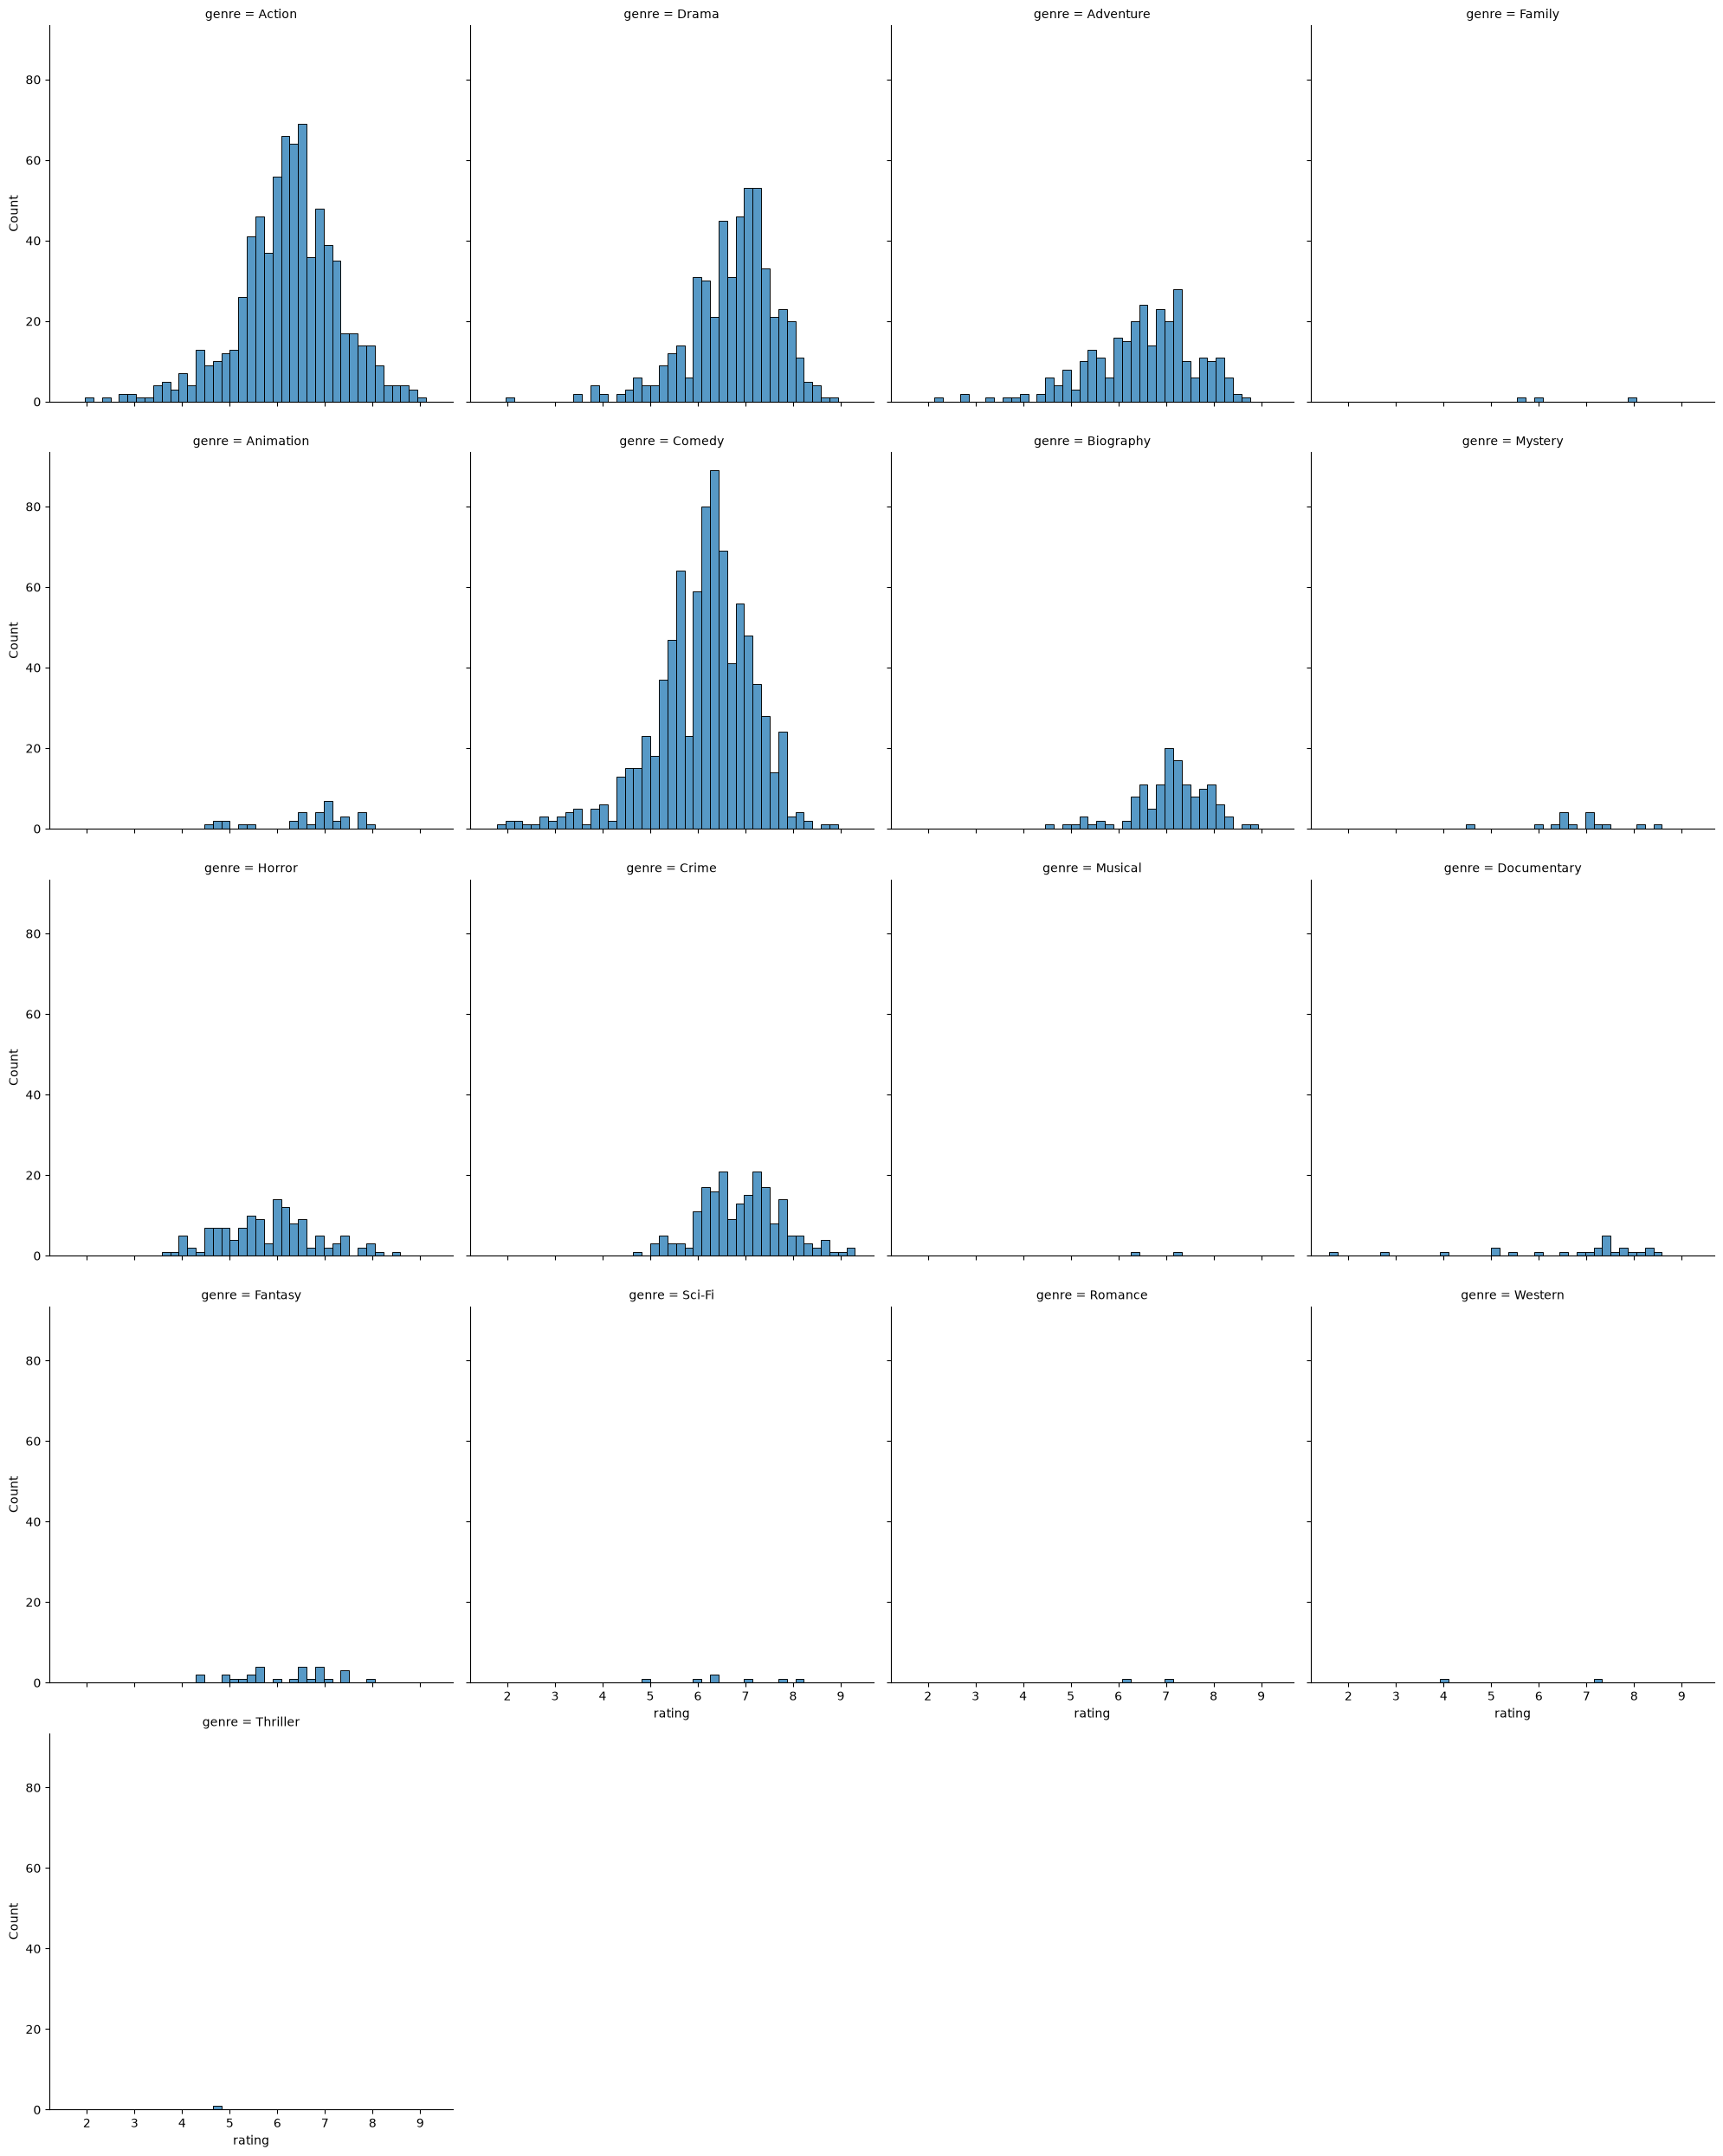

In [42]:
rating_summary = (
    movies.groupby("genre")["rating"]
    .agg(["mean", "min", "max", "median", "std"])
    .reset_index()
)

sns.displot(
    data=movies,
    x="rating",
    col="genre",
    col_wrap=4
)

plt.show()

**Challenge - Produce a table of your own choosing, something you think is important/interesting to have data for, justify your result by writting a 2 sentence explanation/interpretation of the result.**

What is the relationship between movie budget, IMDb rating, and box-office gross among the highest-grossing movies?

In [6]:
top_movies = (
    movies[["title", "gross", "budget", "rating"]]
    .sort_values("gross", ascending=False)
    .head(10)
)

top_movies

,title,gross,budget,rating
0,Avatar,760505847,237000000,7.9
1,Titanic,658672302,200000000,7.7
2,Jurassic World,652177271,150000000,7.0
3,The Avengers,623279547,220000000,8.1
4,The Dark Knight,533316061,185000000,9.0
5,Star Wars: Episode I - The Phantom Menace,474544677,115000000,6.5
6,Star Wars: Episode IV - A New Hope,460935665,11000000,8.7
7,Avengers: Age of Ultron,458991599,250000000,7.5
8,The Dark Knight Rises,448130642,250000000,8.5
9,Shrek 2,436471036,150000000,7.2


The highest-grossing movies generally have large budgets, suggesting that high production investment may be associated with strong box-office performance. However, their IMDb ratings vary, so a high rating does not necessarily guarantee the highest box-office revenue.

#### Use visualisation to answer the following questions

**Examine the relationship between `gross` and `cast_facebook_likes`. Produce a scatterplot and write one sentence discussing whether the number of facebook likes that the cast has received is likely to be a good predictor of how much money a movie will make at the box office. What variable are you going to map to the Y- and X- axes?**

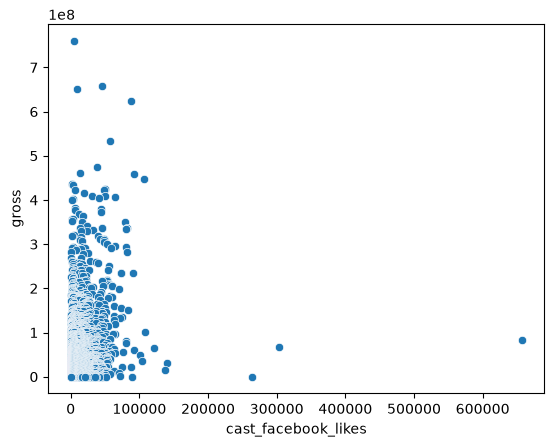

In [44]:
sns.scatterplot(
    data=movies,
    x="cast_facebook_likes",
    y="gross"
)

plt.show()

The scatterplot shows no strong relationship between cast Facebook likes and gross revenue, so Facebook likes alone are probably not a good predictor of box-office performance.

**Examine the relationship between `gross` and `budget`. Produce a scatterplot and write one sentence discussing whether budget is likely to be a good predictor of how much money a movie will make at the box office.**

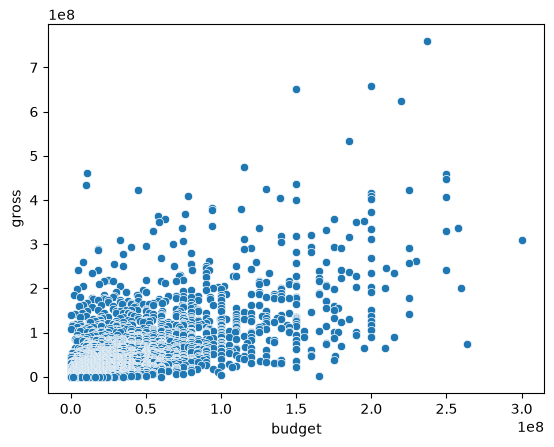

In [45]:
sns.scatterplot(
    data=movies,
    x="budget",
    y="gross"
)

plt.show()

Movies with higher budgets tend to have higher gross revenue, so budget appears to be a better predictor of box-office performance than cast Facebook likes.

**Examine the relationship between `gross` and `rating`. Produce a scatterplot, faceted by `genre` and discuss whether IMDB ratings are likely to be a good predictor of how much money a movie will make at the box office. Is there anything strange in this dataset?**

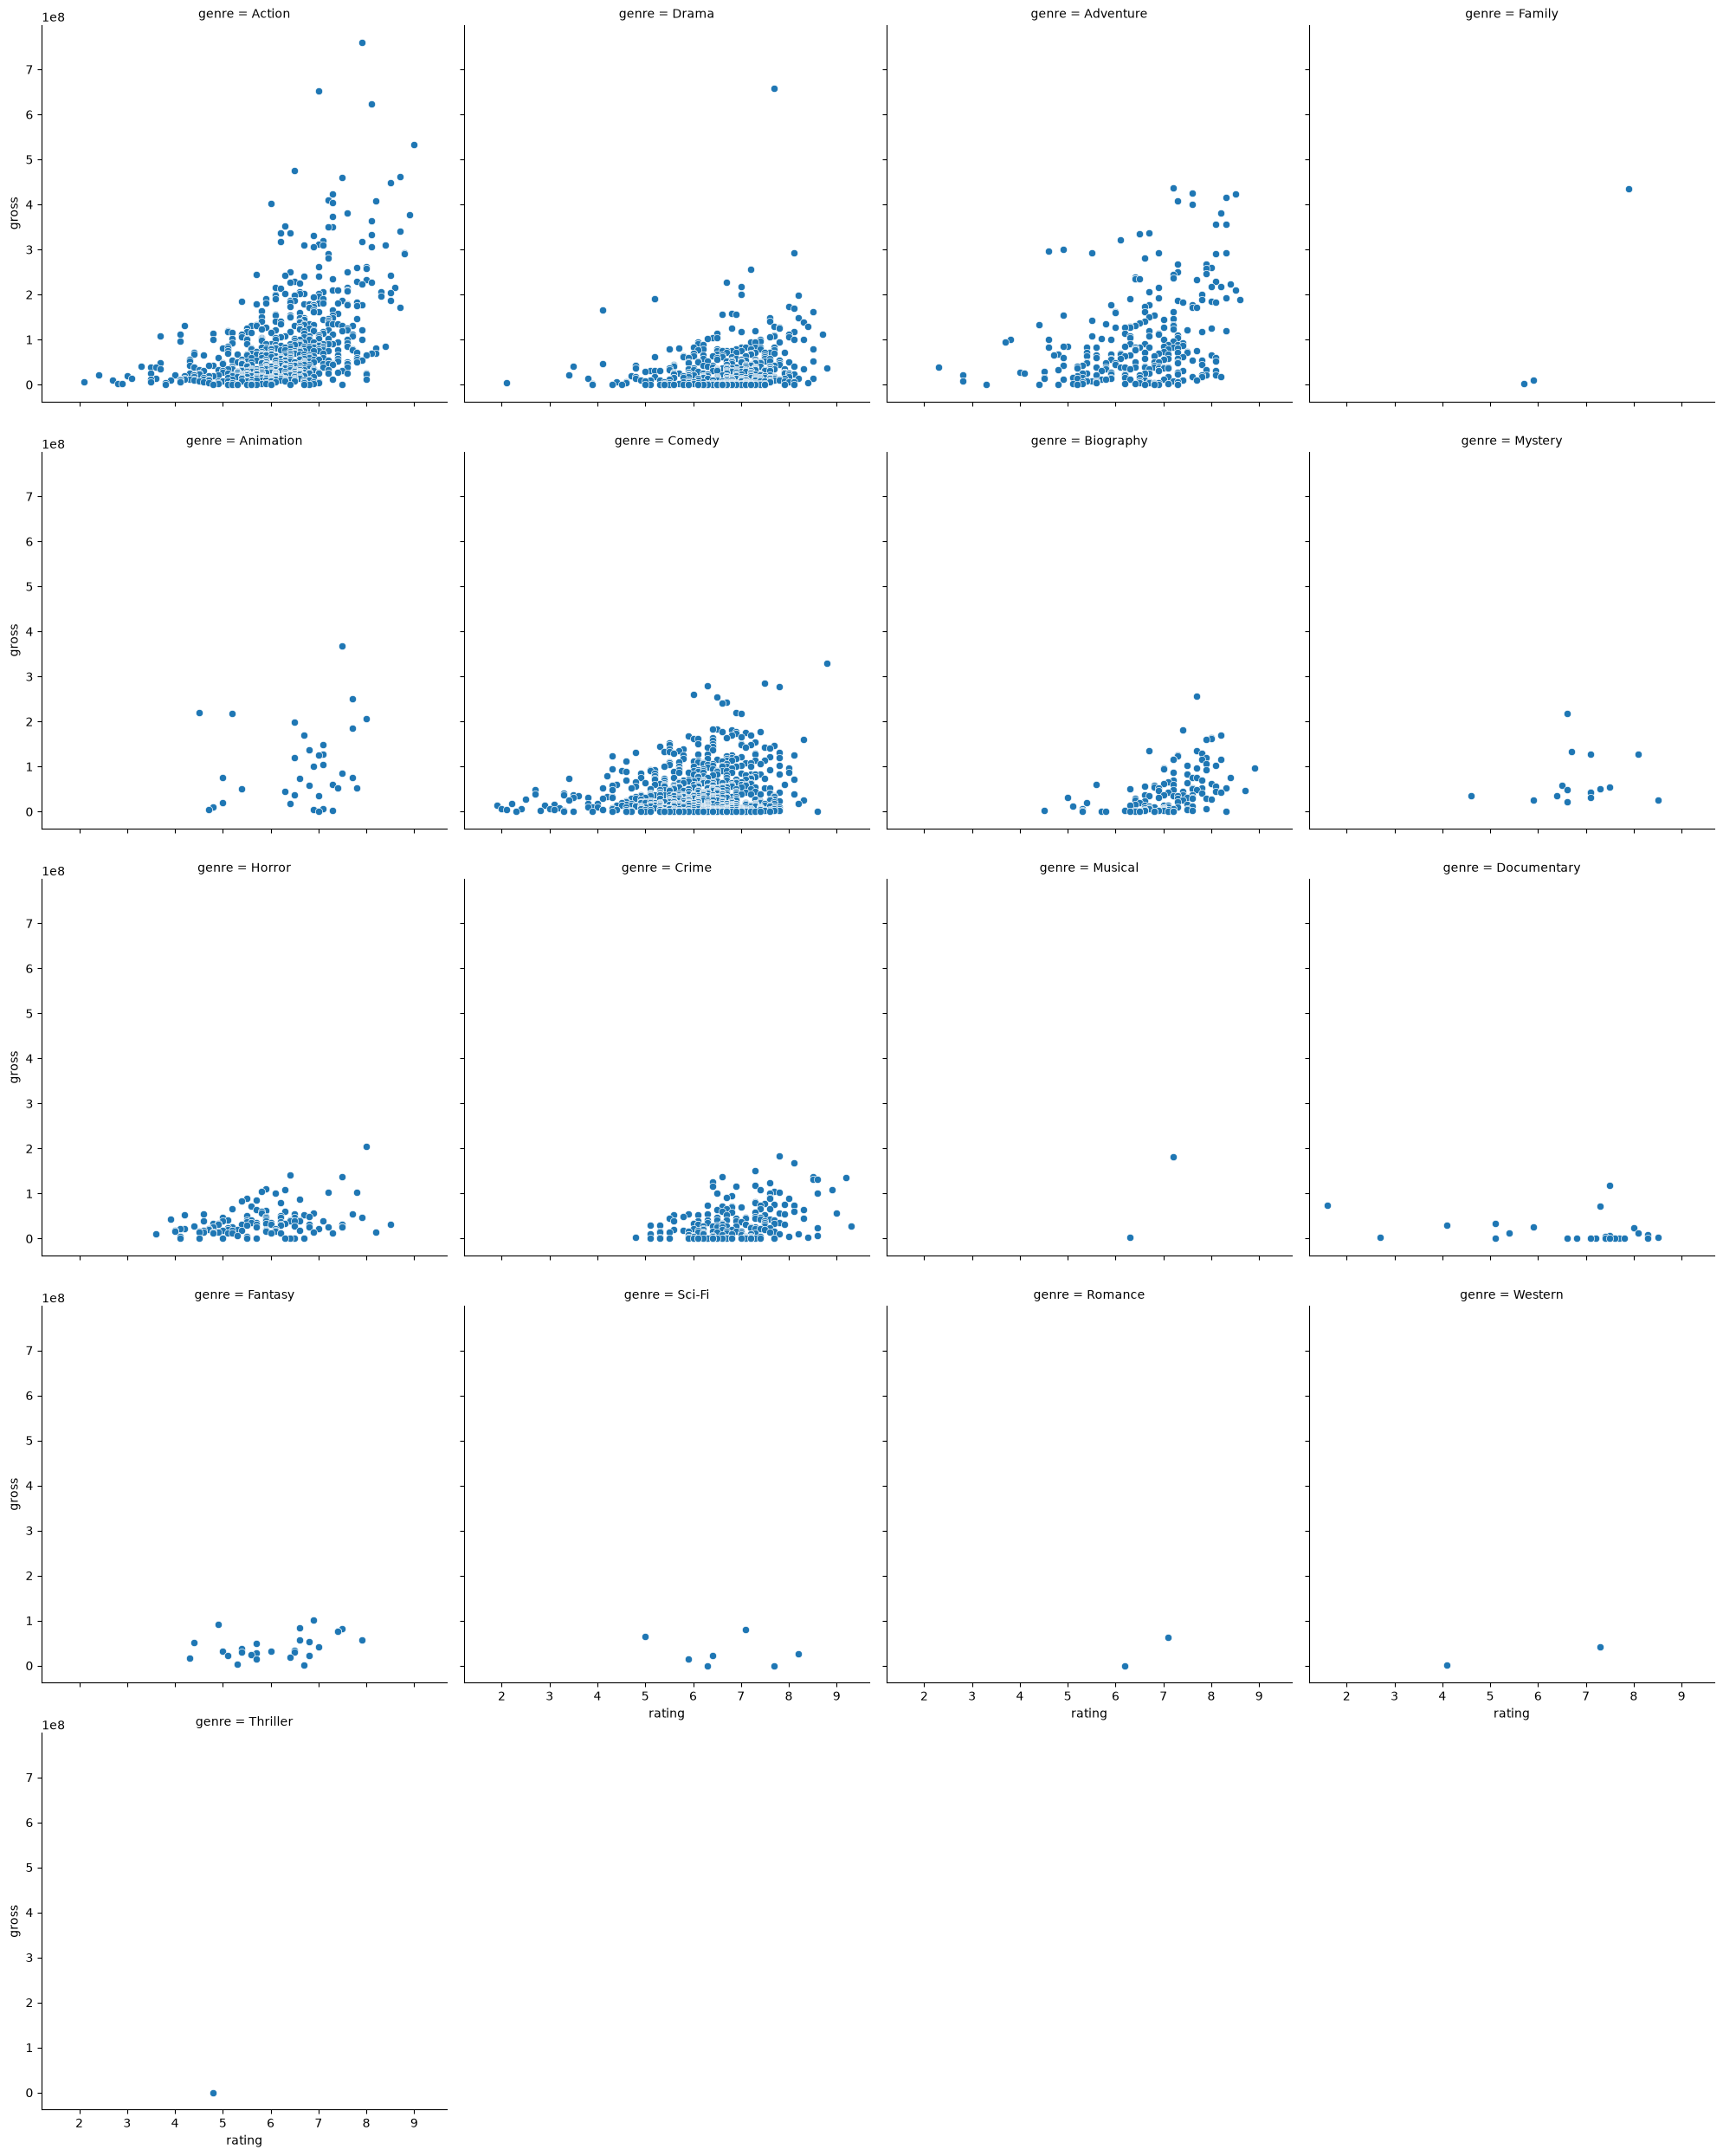

In [46]:
sns.relplot(
    data=movies,
    x="rating",
    y="gross",
    col="genre",
    col_wrap=4,
    kind="scatter"
)

plt.show()

IMDb ratings do not appear to be a strong predictor of box-office gross, as movies with similar ratings can have very different revenues. The dataset also contains very uneven numbers of movies across genres, with some genres having only a few observations.

**Challenge - Produce a visualisation of your choosing, something you think is important to explore/investigate visually. Do make it a comprehensive graph and not a single histogram or density plot. Make it publication ready, label your axes, give it a title, choose colouring options, appropirately formatted text etc.**

Are movies getting longer over time?

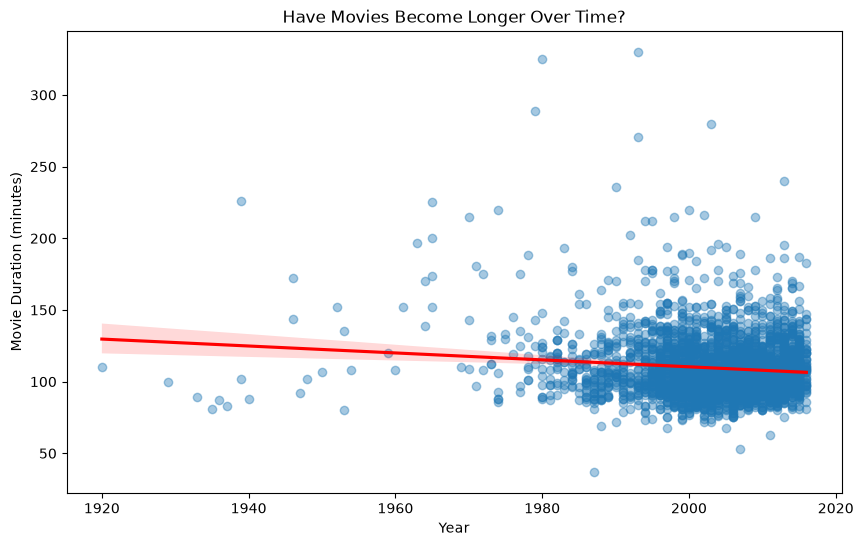

In [47]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=movies,
    x="year",
    y="duration",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title("Have Movies Become Longer Over Time?")
plt.xlabel("Year")
plt.ylabel("Movie Duration (minutes)")

plt.show()

Movie duration appears to decrease slightly over time, but the relationship is weak. The dataset also contains far fewer older movies, so the trend should not be overinterpreted.

### Deliverables

Poduce a clean, stand-alone notebook (or HTML export) with:

All tables/plots properly labeled

Brief interpretations where requested

Upload final HTML/Notebook.